# HuggingFace Example Code
This notebook contains sample code to use HuggingFace to summarize text.

## Set-Up

In [1]:
# Ignore 'np.object' warning associated with TensorFlow/Keras import
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Imports
import torch # Primary deep learning library that we'll use
from torch.utils.data import Dataset, DataLoader # Create and batch custom datasets for training
from transformers import BartTokenizer, BartForConditionalGeneration # Using BART which is good at text summarization
from torch.optim import AdamW # Optimizer for updating model weights during training
from datasets import load_dataset # HuggingFace datasets library for sample data
from rouge_score import rouge_scorer # Metric for evaluating text summary relative to target
from tqdm import tqdm  # For progress bars during training
import matplotlib.pyplot as plt # Use to plot model metrics
import textwrap # Print sample text more legibly

## Load Sample Text to Summarize

In [2]:
# As a sample, load 50 training, 50 validation, and 50 test examples from version 3.0.0 of the data from Hugging Face
raw_train_dataset = load_dataset("cnn_dailymail", "3.0.0", split="train[:50]")
raw_val_dataset = load_dataset("cnn_dailymail", "3.0.0", split="validation[:50]")
raw_test_dataset = load_dataset("cnn_dailymail", "3.0.0", split="test[:50]")

# Extract full articles and summaries for each split
train_texts = raw_train_dataset['article']
train_summaries = raw_train_dataset['highlights']
val_texts = raw_val_dataset['article']
val_summaries = raw_val_dataset['highlights']
test_texts = raw_test_dataset['article']
test_summaries = raw_test_dataset['highlights']

# Take a look at a sample
print("Sample Article:\n", train_texts[0][:200], "...")  # First 200 chars for brevity
print("\nSample Summary:\n", train_summaries[0])

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Sample Article:
 LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on  ...

Sample Summary:
 Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


## Define Dataset Class

In [ ]:
# Create a wrapper that takes raw text data and prepares it for training
# Inherits from PyTorch's built-in Dataset class so that it works with DataLoader later
class SummarizationDataset(Dataset):

    # Store everything as instance variables for later use
    def __init__(
            self,
            texts,
            summaries,
            tokenizer,
            # Setting default to read in only first 200 tokens of each article for speed of training in demonstration
            # BART's maximum max_len_input would be 1024 tokens
            max_len_input=200,
            # Capping decoder output at 100 tokens to save memory
            max_len_output=100):
        self.tokenizer = tokenizer
        self.texts = texts
        self.summaries = summaries
        self.max_len_input = max_len_input
        self.max_len_output = max_len_output

    # Tells PyTorch how many examples are in dataset so that DataLoader knows when it's done iterating
    def __len__(self):
        return len(self.texts)

    # Called for each training example to tokenize it
    def __getitem__(self, idx):

        # Tokenize full input text
        # This is the encoding component, which processes the full input article
        enc = self.tokenizer(
            self.texts[idx],
            # Truncate longer inputs to whatever max_len_input is set to above
            truncation=True,
            # Pad shorter inputs to a fixed length so that all inputs are same length
            padding='max_length',
            # Define the fixed length as whatever max_len_input is set to above
            max_length=self.max_len_input,
            # Return PyTorch tensors for DataLoader, instead of plain lists
            return_tensors="pt"
        )

        # Tokenize the label summaries
        # This is the decoding component, used to train the model on target summaries
        # Same parameters as above, but references summary output instead of text input
        dec = self.tokenizer(
            self.summaries[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len_output,
            return_tensors="pt"
        )

        # Tokenizer converts each text into a dictionary containing two tensors,
        # one tensor for input_ids (token IDs) and one tensor for attention_mask (real=1 or padding=0)
        # Applying squeeze() below summarizes and reformats this information into a format that DataLoader expects
        item = {key: val.squeeze() for key, val in enc.items()}

        # Save token IDs as labels for training to compute loss against
        labels = dec['input_ids'].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100 # Recode pad tokens to placeholder value so they don't affect loss
        item['labels'] = labels

        # Return dictionary with input_ids, attention_mask, and labels for a single example text (one training step)
        return item

## Define Functions

### Function to Initialize Model and Tokenizer

In [4]:
# Load the pre-trained BART model and its matched tokenizer from HuggingFace
# Could swap this out for another model, but may need to update tokenizer and model to match the new model
# Can find recommended tokenizer and model class by clicking "Use this model" button in upper right of model page
def init_model(model_name="facebook/bart-base"):

    # Download and load tokenizer used when model was trained
    tokenizer = BartTokenizer.from_pretrained(model_name)

    # Download and load model weights
    model = BartForConditionalGeneration.from_pretrained(model_name)

    # Return tokenizer to convert text to tokens, and model to process tokens
    return model, tokenizer

### Function to Train the Model

In [ ]:
# Train (fine-tune) the pre-trained BART model on our training dataset
def train_model(
        # Pre-trained model loaded by init_model() above, which will get updated during fine-tuning
        model,
        # DataLoader that will feed batches of tokenized articles and labels into model during training
        dataloader,
        # Tells PyTorch where to run computations, must match available hardware
        # "mps" (Mac GPU), "cuda" (NVIDIA GPU), or "cpu"
        device,
        # Tokenizer loaded by init_model() above, used in this function to decode token IDs back into text
        tokenizer,
        # Raw validation article strings to be tokenized in this function, used to generate summaries to score
        val_texts,
        # Validation target summary strings to compare generated summaries against
        val_summaries,
        # Default number of times to loop through the full dataset
        epochs=5,
        # Default learning rate, how big each weight update is (too high will overshoot, too low will be too slow)
        lr=5e-5,
        # Filepath to save best model weights wth a PyTorch file extension
        checkpoint_path="checkpoint.pt",
        # Default number of samples for ROUGE to evaluate after each epoch, set low for efficience of demonstration
        eval_samples=10
        ):
    
    # Typcial optimizer used in transformer training to update model weights during backpropagation
    optimizer = AdamW(model.parameters(), lr=lr)

    # Initialize variable that will track lowest training loss and trigger saving of checkpoint
    best_loss = float('inf')

    # Move model to defined hardware
    model.to(device)

    # Use Recall-Oriented Understudy for Gisting Evaluation (ROUGE) to evaluate generated summaries against reference summaries
    # We perform ROUGE on the validation set to avoid inflating performance of the metrics
    # Create a ROUGE object first
    # ROUGE-1: counts overlap of individual words
    # ROUGE 2: counts overlap of two-word pairs (bigrams), stricter than ROUGE-1
    # ROUGE-L: looks for longest common sequence of words appearing in both, whether overall sentence structure similar
    rouge = rouge_scorer.RougeScorer(
        ['rouge1','rouge2','rougeL'],
        use_stemmer=True # Reduce words to base form to facilitate matching
    )

    # Initialize list to hold scores
    rouge_scores_per_epoch = []

    # Each epoch is a full pass through the dataset
    for epoch in range(epochs):

        # Put model in training mode
        model.train()

        # Initialize variable to accumulate loss
        total_loss = 0

        # Train (fine-tune) on the training data
        # Loop through all batches, with a progress bar to visualize progress
        for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=True):

            # Clear prior gradients
            optimizer.zero_grad()

            # Move the batch to the device
            input_ids = batch['input_ids'].to(device) # Token IDs representing the article
            attention_mask = batch['attention_mask'].to(device) # Binary indicator of real token vs. padding token
            labels = batch['labels'].to(device) # Target summary tokens

            # Run the model
            # Encoder will read article, decoder will predict summary tokens, loss will be computed against labels
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

            # Extract loss (prediction error)
            # Lower loss means better predictions
            # The HuggingFace BART model uses cross entropy loss as a default
            loss = outputs.loss

            # Backpropagation algorithm computes the gradients to tell us how much the weights should change
            loss.backward()

            # Use gradients to update weights
            optimizer.step()

            # Accumulate the loss
            total_loss += loss.item()

        # Compute the average loss as total loss divided by number of batches
        avg_loss = total_loss / len(dataloader)

        # Print a progress indicator
        print(f"Epoch {epoch+1} finished - Avg Loss: {avg_loss:.4f}")

        # Evaluate ROUGE on first few samples
        # Switch to evaluation mode to ensure deterministic predictions
        model.eval()

        # Initiate a list to store generated summaries
        generated = []

        # Generate sample summaries for calculating ROUGE scores
        with torch.no_grad(): # Save memory by not tracking gradients during inference
            
            # For the number of samples defined in the function parameters
            for i in range(eval_samples):

                # Tokenize the validation article
                inputs = tokenizer(
                    val_texts[i],
                    return_tensors="pt", # Convert text to tokens wrapped in PyTorch tensors
                    max_length=200, # Truncates if longer than 200 tokens
                    truncation=True
                )

                # Send the tokenized article to hardware
                inputs = {k: v.to(device) for k, v in inputs.items()}

                # Use the BART decoder to generate a summary
                summary_ids = model.generate(
                    input_ids=inputs['input_ids'],
                    attention_mask=inputs['attention_mask'],
                    max_length=100, # Summary can be maximum of 100 tokens long
                    min_length=10, # Summary must be at least 10 tokens long
                    num_beams=4, # Explore multiple candidate summaries through beam search
                    no_repeat_ngram_size=2, # Prevent repeated phrases
                    early_stopping=True # Stop when beam search finds good completion
                )

                # Decode the summary
                # Converts token IDs into a human-readable string
                gen_summary = tokenizer.decode(
                    summary_ids[0], # Get the best one from beam search
                    skip_special_tokens=True # Removes certain special tokens inserted by Hugging Face
                )

                # Save generated summary
                generated.append(gen_summary)

        # Compute ROUGE, a measure of word overlap (not a measure of meaning overlap)
        # Each ROUGE version returns a score between 0 and 1, where 1 is a perfect match
        scores = [rouge.score(val_summaries[i], generated[i]) for i in range(eval_samples)] # Compare to reference summary
        avg_rouge1 = sum([s['rouge1'].fmeasure for s in scores]) / eval_samples # F-measure values balance precision and recall
        avg_rouge2 = sum([s['rouge2'].fmeasure for s in scores]) / eval_samples
        avg_rougeL = sum([s['rougeL'].fmeasure for s in scores]) / eval_samples
        rouge_scores_per_epoch.append((avg_rouge1, avg_rouge2, avg_rougeL))
        print(f"ROUGE-1: {avg_rouge1:.3f}, ROUGE-2: {avg_rouge2:.3f}, ROUGE-L: {avg_rougeL:.3f}")

        # Save checkpoint
        if avg_loss < best_loss: # If current model is an improvement
            best_loss = avg_loss # Update best loss
            torch.save(model.state_dict(), checkpoint_path) # Save weights
            print(f"Checkpoint saved at epoch {epoch+1}")
        print() # Print a blank line for readability

    # Load best model (not necessarily the last epoch)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    # Set the model to be ready for inference
    model.eval()

    # Return trained model and scores
    return model, rouge_scores_per_epoch

### Function to Generate Summaries

In [6]:
# Use trained (fine-tuned) model to generate summaries for every article in input dataset,
# and return as list of strings for printing
# This is different from the summaries generated in train_model() because
# in train_model() only a couple of summaries are generated, for ROUGE evaluation,
# while in generate_summaries() we get final output to demonstrate results
def generate_summaries(      
        model, # Fine-tuned BART model that's already been trained
        dataset, # Preprocessed tokenized dataset of input_ids and attention_mask
        tokenizer, # For converting token IDs to human-readable text
        device, # Your hardware, must match where the model is
        max_length=100, # Summary can be maximum of 100 tokens long
        min_length=10, # Summary must be at least 10 tokens long
        num_beams=4 # Explore multiple candidate summaries through beam search
        ):
    
    # Initialize a list to store summaries
    summaries_out = []

    # Generate full set of output summaries for review
    with torch.no_grad(): # Save memory by not tracking gradients during inference
        
        # Loop over the input articles
        for i in range(len(dataset)):
            item = dataset[i]

            # Set the inputs to the required dimensions using unsqueeze()
            # And send it to your hardware
            input_ids = item['input_ids'].unsqueeze(0).to(device)
            attention_mask = item['attention_mask'].unsqueeze(0).to(device)

            # Generate output tokens
            summary_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=max_length,
                min_length=min_length,
                num_beams=num_beams,
                no_repeat_ngram_size=2, # Prevent repeating two-word phrases
                early_stopping=True # Stops beam search to save computation time
            )

            # Decode tokens into text
            summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

            # Store summary
            summaries_out.append(summary)
    
    # Return full list of generated summaries
    return summaries_out

### Function to Implement Full Pipeline

In [7]:
def main():

    # Set the hardware
    device = torch.device("cuda" if torch.cuda.is_available() else # NVIDIA GPU
                          "mps" if torch.backends.mps.is_available() else # Apple GPU
                          "cpu")

    # Initialize model and tokenizer
    model, tokenizer = init_model()

    # Define training and test datasets
    # Note we don't actually need val_dataset in our following code, so it's not constructed here
    train_dataset = SummarizationDataset(train_texts, train_summaries, tokenizer, max_len_input=200, max_len_output=100)
    test_dataset = SummarizationDataset(test_texts, test_summaries, tokenizer, max_len_input=200, max_len_output=100)
    
    # Note that DataLoader is defined using the training set, so that the train_model batch loop iterates over training examples
    dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)

    # Train model using dataloader (defined on the training set) and inputting validation texts and summaries for ROUGE evaluation
    model, rouge_scores = train_model(model, dataloader, device, tokenizer, val_texts, val_summaries,
                                    epochs=5, lr=5e-5, eval_samples=10)

    # Plot ROUGE scores
    epochs_range = range(1, len(rouge_scores) + 1)
    plt.plot(epochs_range, [s[0] for s in rouge_scores], label="ROUGE-1", marker='o')
    plt.plot(epochs_range, [s[1] for s in rouge_scores], label="ROUGE-2", marker='o')
    plt.plot(epochs_range, [s[2] for s in rouge_scores], label="ROUGE-L", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.title("ROUGE Scores per Epoch (Validation Set)")
    plt.ylim(0, 1)
    plt.xticks(epochs_range)
    plt.legend()
    plt.show()

    # Generate summaries on the test dataset
    summaries_out = generate_summaries(model, test_dataset, tokenizer, device)
    for i in range(5):
        print(f"\n{'='*100}")
        print(f"Example {i+1}")
        print(f"{'='*100}")
        print(f"ORIGINAL (EXCERPT):")
        print(textwrap.fill(test_texts[i][:200] + "...", width=100))
        print(f"\nTARGET SUMMARY:")
        print(textwrap.fill(test_summaries[i], width=100))
        print(f"\nGENERATED SUMMARY:")
        print(textwrap.fill(summaries_out[i], width=100))

## Summarize the Sample Text

Epoch 1/5: 100%|██████████| 13/13 [00:16<00:00,  1.30s/it]


Epoch 1 finished - Avg Loss: 3.8372
ROUGE-1: 0.301, ROUGE-2: 0.115, ROUGE-L: 0.229
Checkpoint saved at epoch 1



Epoch 2/5: 100%|██████████| 13/13 [00:40<00:00,  3.08s/it]


Epoch 2 finished - Avg Loss: 2.7048
ROUGE-1: 0.295, ROUGE-2: 0.099, ROUGE-L: 0.234
Checkpoint saved at epoch 2



Epoch 3/5: 100%|██████████| 13/13 [00:33<00:00,  2.54s/it]


Epoch 3 finished - Avg Loss: 1.9562
ROUGE-1: 0.285, ROUGE-2: 0.100, ROUGE-L: 0.218
Checkpoint saved at epoch 3



Epoch 4/5: 100%|██████████| 13/13 [00:38<00:00,  2.97s/it]


Epoch 4 finished - Avg Loss: 1.5763
ROUGE-1: 0.257, ROUGE-2: 0.068, ROUGE-L: 0.201
Checkpoint saved at epoch 4



Epoch 5/5: 100%|██████████| 13/13 [01:18<00:00,  6.05s/it]


Epoch 5 finished - Avg Loss: 1.2308
ROUGE-1: 0.313, ROUGE-2: 0.113, ROUGE-L: 0.226
Checkpoint saved at epoch 5



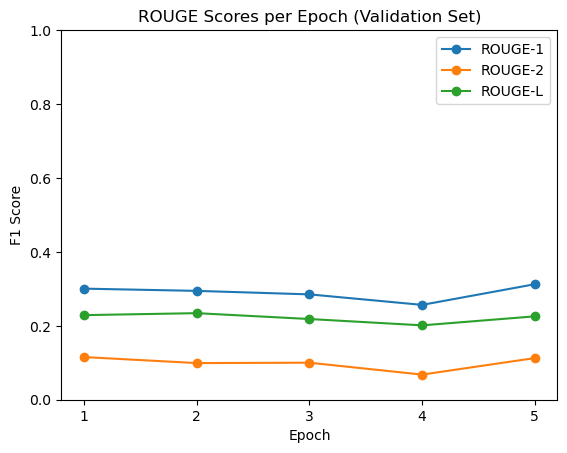


Example 1
ORIGINAL (EXCERPT):
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal
Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian
territor...

TARGET SUMMARY:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since
last June . Israel and the United States opposed the move, which could open the door to war crimes
investigations against Israelis .

GENERATED SUMMARY:
Palestinian Authority becomes 123rd member of the International Criminal Court on Wednesday, a step
that gives the court jurisdiction over alleged crimes in Palestinian territories .

Example 2
ORIGINAL (EXCERPT):
(CNN)Never mind cats having nine lives. A stray pooch in Washington State has used up at least three
of her own after being hit by a car, apparently whacked on the head with a hammer in a misguided
me...

TARGET SUMMARY:
Theia, a bully breed mix, was apparently hit by a car, whac

In [ ]:
# Run the main function
# In a Jupyter notebook, you can just call the function directly
# But in a .py script you would need to use the wrapper if __name__ == "__main__":
main()

# Note, due to our small sample size for this example the ROUGE scores may just reflect noise

## Clean Up Your Environment

In [9]:
# Clear cached models and datasets from testing to free up disk space
# Note if you get messages about MallocStackLogging they are harmless
!rm -rf ~/.cache/huggingface/datasets/cnn_dailymail
!rm -rf ~/.cache/huggingface/transformers

python(37821) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37851) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
